In [1]:
import pandas as pd
data = pd.read_excel("iris_dataset.xlsx")
data

,SepalLCm,SepalWidthCm,PetalLCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [2]:
from sklearn.model_selection import train_test_split
data_train,data_test=train_test_split(data,test_size=0.2)
data_test.to_excel("test.xlsx",index=False)
data_train.to_excel("train.xlsx",index=False)

In [11]:
data_test= pd.read_excel("test.xlsx")
data_test
truth=data_test["Species"]

In [3]:
from mlforkidsnumbers import MLforKidsNumbers

project = MLforKidsNumbers(
    modelurl="https://mlforkids-newnumbers.j8ayd8ayn23.eu-de.codeengine.appdomain.cloud/saved-models/auth0|6a52566cf097b0cf74d56e90-4/status"
)


 MLforKids : Checking for downloaded model... 
 MLforKids : Getting model info... 
 MLforKids : Preparing for download... 
 MLforKids : Downloading model... 
 MLforKids : Unpacking model... 
 MLforKids : Loading model... 
 MLforKids : Accessing model metadata... 
 MLforKids : Model trained at 2026-09-30T12:04:44.983049 


,SepalLCm,SepalWidthCm,PetalLCm,PetalWidthCm,Species
0,6.1,2.8,4.7,1.2,versicolor
1,6.2,2.2,4.5,1.5,versicolor
2,5.5,2.5,4.0,1.3,versicolor
3,4.6,3.6,1.0,0.2,setosa
4,6.4,2.9,4.3,1.3,versicolor
5,6.1,2.8,4.0,1.3,versicolor
6,6.0,3.0,4.8,1.8,virginica
7,4.4,2.9,1.4,0.2,setosa
8,5.0,3.2,1.2,0.2,setosa
9,6.3,2.3,4.4,1.3,versicolor


In [9]:
data_test.columns

Index(['SepalLCm', 'SepalWidthCm', 'PetalLCm', 'PetalWidthCm', 'Species'], dtype='str')

In [14]:
prediction_1=[]
for i in range(30):
    prediction=project.predict({
        "SepalLCm":data_test.iloc[i]["SepalLCm"],
        "SepalWidthCm" : data_test.iloc[i]["SepalWidthCm"],
        "PetalLCm" : data_test.iloc[i]["PetalLCm"],
        "PetalWidthCm" : data_test.iloc[i]["PetalWidthCm"],
    }
    )
    prediction_1.append(prediction[0]["class_name"])
prediction_1

['versicolor',
 'versicolor',
 'versicolor',
 'setosa',
 'versicolor',
 'versicolor',
 'virginica',
 'setosa',
 'setosa',
 'versicolor',
 'virginica',
 'setosa',
 'virginica',
 'virginica',
 'setosa',
 'versicolor',
 'setosa',
 'setosa',
 'versicolor',
 'virginica',
 'setosa',
 'versicolor',
 'setosa',
 'virginica',
 'versicolor',
 'setosa',
 'versicolor',
 'virginica',
 'setosa',
 'versicolor']

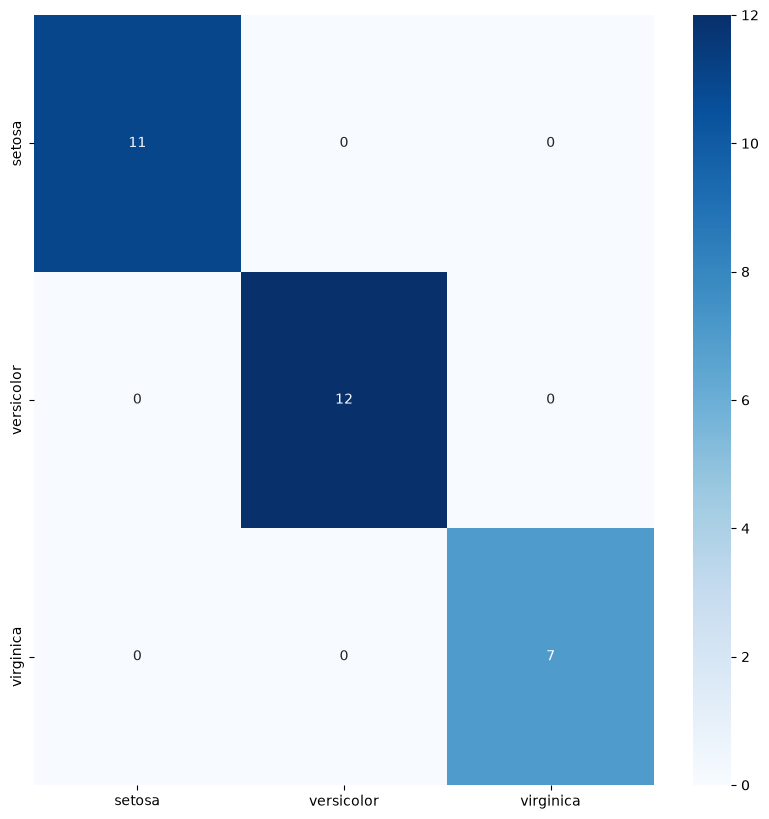

In [15]:
from sklearn.metrics import  confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(truth,prediction_1,labels=["setosa","versicolor","virginica"])
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,xticklabels=["setosa","versicolor","virginica"],yticklabels=["setosa","versicolor","virginica"],cmap="Blues")

plt.show()

In [ ]:
from sklearn.metrics import  classification_report

print(classification_report(truth,prediction_1))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      1.00      1.00        12
   virginica       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



: 

In [ ]:
accuracy_score(truth,prediction_1)